### **LinearNormalization Node**  
Example from pipeline.yaml:

<code> - <font color='green'>name: normalization</font>
    algorithm:    
      class_name: <font color='blue'>iris.LinearNormalization</font>
      params: {}</code> If this is empty, the default values are used.
      
<code>    inputs:
      - name: image
        source_node: input
      - name: noise_mask
        source_node: noise_masks_aggregation
      - name: extrapolated_contours
        source_node: geometry_estimation
      - name: eye_orientation
        source_node: eye_orientation
    callbacks:</code>

**What it does**

LinearNormalization converts the iris from its natural circular form in the original image into a flat rectangular strip. It was originally mentioned in the Daugman paper called [How Iris Recognition Works](https://www.robots.ox.ac.uk/~az/lectures/est/iris.pdf). To do so, pixels are sampled along evenly spaced radial lines between the pupil and iris boundaries, basically "unrolling" the iris. It makes the iris texture consistent regardless of pupil dilation or eye rotation. 

**Key parameters**


| Parameter | Default Value | What it controls |
|---|---|---|
| res_in_r | 128 | Height of the output strip - how many radial sampels to take between pupil and iris boundary. Higher values represent more detail in the radial direction |
| oversat_threshold | 254 | Pixel brightness value above which a pixel is considered oversaturated and treated as noise. Maximum value is 255. |


**Code \& Visualization Cells**


In [15]:
import cv2
import iris
from pathlib import Path
from iris.nodes.normalization.linear_normalization import LinearNormalization

# ---- Load image ----
img_path = Path.home() / "Downloads/current_courses/CMSE495/example_orb_image_1.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
noise_mask = pipeline.call_trace.get("noise_masks_aggregation")
geometry   = pipeline.call_trace.get("geometry_estimation")
eye_orient = pipeline.call_trace.get("eye_orientation")

print("noise_mask type:", type(noise_mask))
print("geometry type:  ", type(geometry))
print("eye_orient type:", type(eye_orient))

# ---- Run LinearNormalization in isolation ----
node = LinearNormalization(res_in_r=128, oversat_threshold=254)

result = node.run(
    image=ir_image,
    noise_mask=noise_mask,
    extrapolated_contours=geometry,
    eye_orientation=eye_orient
)

print("\nResult type:", type(result))
print("Normalized image shape:", result.normalized_image.shape)
print("Normalized mask shape: ", result.normalized_mask.shape)

noise_mask type: <class 'iris.io.dataclasses.NoiseMask'>
geometry type:   <class 'iris.io.dataclasses.GeometryPolygons'>
eye_orient type: <class 'iris.io.dataclasses.EyeOrientation'>

Result type: <class 'iris.io.dataclasses.NormalizedIris'>
Normalized image shape: (128, 512)
Normalized mask shape:  (128, 512)


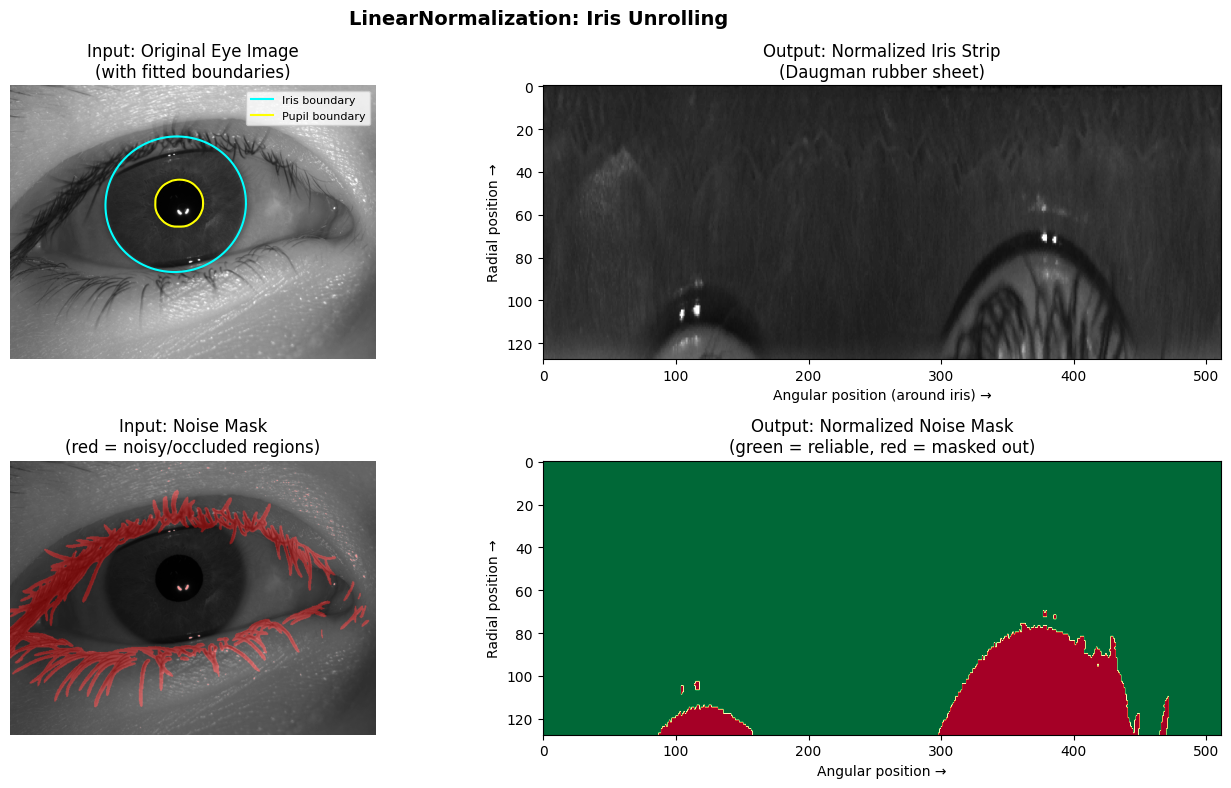

Reliable iris area: 9.5%
Normalized strip dimensions: (128, 512) (height x width)
Eye orientation angle: -0.0955 radians (-5.47 degrees)


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top left: original eye image with iris/pupil boundaries overlaid
axes[0, 0].imshow(img_pixels, cmap="gray")
iris_pts = geometry.iris_array
pupil_pts = geometry.pupil_array
axes[0, 0].plot(iris_pts[:, 0], iris_pts[:, 1], 
                "cyan", linewidth=1.5, label="Iris boundary")
axes[0, 0].plot(pupil_pts[:, 0], pupil_pts[:, 1], 
                "yellow", linewidth=1.5, label="Pupil boundary")
axes[0, 0].legend(loc="upper right", fontsize=8)
axes[0, 0].set_title("Input: Original Eye Image\n(with fitted boundaries)")
axes[0, 0].axis("off")

# Top right: normalized iris strip
axes[0, 1].imshow(result.normalized_image, cmap="gray", aspect="auto")
axes[0, 1].set_title("Output: Normalized Iris Strip\n(Daugman rubber sheet)")
axes[0, 1].set_xlabel("Angular position (around iris) →")
axes[0, 1].set_ylabel("Radial position →")

# Bottom left: noise mask overlaid on original image
noise_display = np.zeros((*img_pixels.shape, 3), dtype=np.uint8)
noise_display[..., 0] = noise_mask.mask.astype(np.uint8) * 255
axes[1, 0].imshow(img_pixels, cmap="gray")
axes[1, 0].imshow(noise_display, alpha=0.4)
axes[1, 0].set_title("Input: Noise Mask\n(red = noisy/occluded regions)")
axes[1, 0].axis("off")

# Bottom right: normalized mask
axes[1, 1].imshow(result.normalized_mask, cmap="RdYlGn", aspect="auto")
axes[1, 1].set_title("Output: Normalized Noise Mask\n(green = reliable, red = masked out)")
axes[1, 1].set_xlabel("Angular position →")
axes[1, 1].set_ylabel("Radial position →")

plt.suptitle("LinearNormalization: Iris Unrolling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Stats
reliable_pct = (1 - result.normalized_mask.mean()) * 100
print(f"Reliable iris area: {reliable_pct:.1f}%")
print(f"Normalized strip dimensions: {result.normalized_image.shape} (height x width)")
print(f"Eye orientation angle: {eye_orient.angle:.4f} radians ({np.degrees(eye_orient.angle):.2f} degrees)")

The strip should look like a flattened ring of iris texture - you should see the radial fiber patterns of the iris running approximately vertically across the strip with relatively consistent brightness across the width. The noise mask should be mostly green/clean with red regions only at the top and bottom edges where eyelids occlude the iris.

What you seeWhat it meansLarge red/masked regions in the center of the stripHeavy eyelid occlusion — this image may be rejected by the occlusion validatorsUniform gray strip with no visible textureIris boundary was fitted incorrectly — normalization sampled outside the irisBright horizontal bandsSpecular reflections weren't fully masked, corrupting the textureStrip looks "stretched" on one sideEye was off-gaze, causing uneven sampling around the boundaryVery narrow stripres_in_r is low, or the pupil and iris boundaries are very close together

**What to look for** (what does a good output look like vs bad) 

### SharpnessEstimation Node  
Example from pipeline.yaml:

<code>   - <font color='green'>name: sharpness_estimation</font>
    algorithm:
      class_name: <font color='blue'>iris.SharpnessEstimation</font>
      params: {}
    inputs:
      - name: normalization_output
        source_node: normalization
    callbacks:
      - class_name: <font color='blue'>iris.nodes.validators.object_validators.SharpnessValidator</font>
        params:
          min_sharpness: 461.0</code>

**What it does** (2-3 sentences, plain English)  

**Key parameters** (table of param name, default, what it controls)  

**Code cell** (run just this node in isolation)  

**Visualization cell** (matplotlib showing input vs output)  

**What to look for** (what does a good output look like vs bad) 

---


### Filter Bank Node  
Example from pipeline.yaml:

<code>  - <font color='green'>name: filter_bank</font>
    algorithm:
      class_name: <font color='blue'>iris.ConvFilterBank</font>
      params:
        maskisduplicated: False
        filters:
          - class_name: <font color='blue'>iris.GaborFilter</font>
            params:
              kernel_size: [41, 21]
              sigma_phi: 7
              sigma_rho: 6.13
              theta_degrees: 90.0
              lambda_phi: 28.0
              dc_correction: True
              to_fixpoints: True
          - class_name: <font color='blue'>iris.GaborFilter</font>
            params:
              kernel_size: [17, 21]
              sigma_phi: 2
              sigma_rho: 5.86
              theta_degrees: 90.0
              lambda_phi: 8
              dc_correction: True
              to_fixpoints: True
        probe_schemas:
          - class_name: <font color='blue'>iris.RegularProbeSchema</font>
            params:
              n_rows: 16
              n_cols: 256
          - class_name: <font color='blue'>iris.RegularProbeSchema</font>
            params:
              n_rows: 16
              n_cols: 256
    inputs:
      - name: normalization_output
        source_node: normalization
    callbacks:</code>

**What it does** (2-3 sentences, plain English)  

**Key parameters** (table of param name, default, what it controls)  

**Code cell** (run just this node in isolation)  

**Visualization cell** (matplotlib showing input vs output)  

**What to look for** (what does a good output look like vs bad) 

---


### Iris Response Refinement 
Example from pipeline.yaml:

<code>      - <font color='green'>name: iris_response_refinement</font>
    algorithm:
      class_name: <font color='blue'>iris.nodes.iris_response_refinement.fragile_bits_refinement.FragileBitRefinement</font>
      params:
        value_threshold:  [0.0001, 0.275, 0.08726646259971647]
        fragile_type: "polar"
        maskisduplicated: False
    inputs:
      - name: response
        source_node: filter_bank
    callbacks:</code>

**What it does** (2-3 sentences, plain English)  

**Key parameters** (table of param name, default, what it controls)  

**Code cell** (run just this node in isolation)  

**Visualization cell** (matplotlib showing input vs output)  

**What to look for** (what does a good output look like vs bad) 

---

### Encoder
Example from pipeline.yaml:

<code>   - <font color='green'>name: encoder</font>
    algorithm:
      class_name: <font color='blue'>iris.IrisEncoder</font>
      params: {}
    inputs:
      - name: response
        source_node: iris_response_refinement
    callbacks:
      - class_name: <font color='blue'>iris.nodes.validators.object_validators.IsMaskTooSmallValidator</font>
        params:
          min_maskcodes_size: 4096</code>

**What it does** (2-3 sentences, plain English)  

**Key parameters** (table of param name, default, what it controls)  

**Code cell** (run just this node in isolation)  

**Visualization cell** (matplotlib showing input vs output)  

**What to look for** (what does a good output look like vs bad) 

---

### Bounding Box Estimation
Example from pipeline.yaml:

<code>  - <font color='green'>name: bounding_box_estimation</font>
    algorithm:
      class_name: <font color='blue'>iris.IrisBBoxCalculator</font>
      params: {}
    inputs:
      - name: ir_image
        source_node: input
      - name: geometry_polygons
        source_node: geometry_estimation
    callbacks:</code>

**What it does** (2-3 sentences, plain English)  

**Key parameters** (table of param name, default, what it controls)  

**Code cell** (run just this node in isolation)  

**Visualization cell** (matplotlib showing input vs output)  

**What to look for** (what does a good output look like vs bad) 